In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy as cp
import time
import pathlib

from scripts import power_system_simulation as sim

base_dir = pathlib.Path(".")
system_dir = base_dir / "RTS-GMLC-master" / "RTS_Data"

In [8]:
# 1. Instantiate system
system = sim.System(base_dir, system_dir)

# 2. Read in time series for a particular year
year = 2006
system.read_timeseries(year)

# 3. Create model
system.write_opf()

In [9]:
### Reliability Simulation ###

# Simulate each day in data set
df_results = pd.DataFrame(index=pd.date_range(f"{year}-01-01 00:00:00", f"{year}-12-31 23:59:59", freq="h"), columns=["Cost", "Unserved Energy"])
df_LMP = pd.DataFrame(index=df_results.index, columns=list(system.nodes.keys()))
start = time.time()
for date in df_results.index[::sim.T]:
    if date + pd.Timedelta(hours=sim.T) > df_results.index.max():
        break
    
    # Re-solve model
    system.solve_opf(date)

    # Save results
    df_results.loc[date, "Cost"] = system.total_variable_costs.value
    df_results.loc[date, "Unserved Energy"] = cp.sum(cp.sum([n.unserved_energy for n in system.nodes.values()])).value
    for n in system.nodes.keys():
        df_LMP.loc[date:date + pd.Timedelta(hours=sim.T-1), n] = system.nodes[n].power_balance_constraint.dual_value
        
        
end = time.time()
time_elapsed = end - start
print(f"Total Elapsed Time: {time_elapsed:.1f}s")

Total Elapsed Time: 58.7s


In [56]:
df_results.dropna().mean()

Cost               1531837.370032
Unserved Energy               0.0
dtype: object

<Axes: >

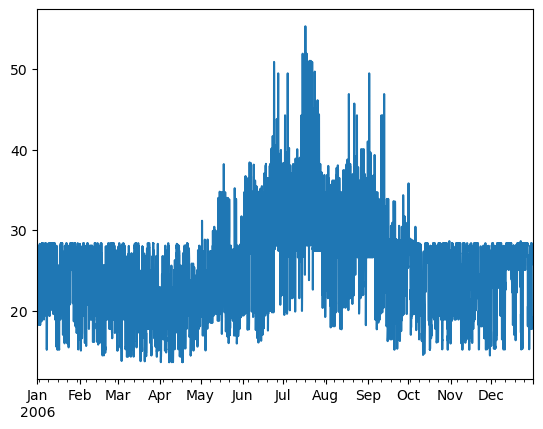

In [26]:
df_LMP.mean(axis=1).plot()

<Axes: >

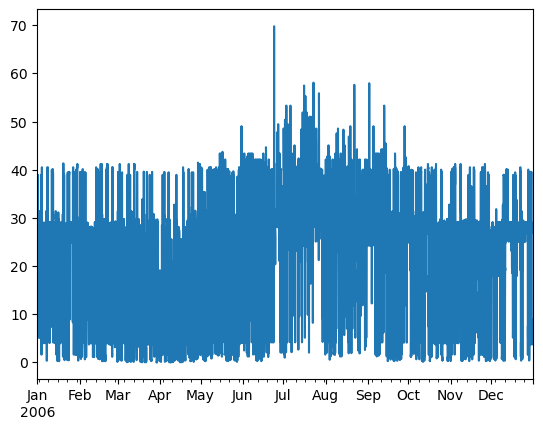

In [18]:
df_LMP[df_LMP.max(axis=0).idxmax()].plot()

<Axes: >

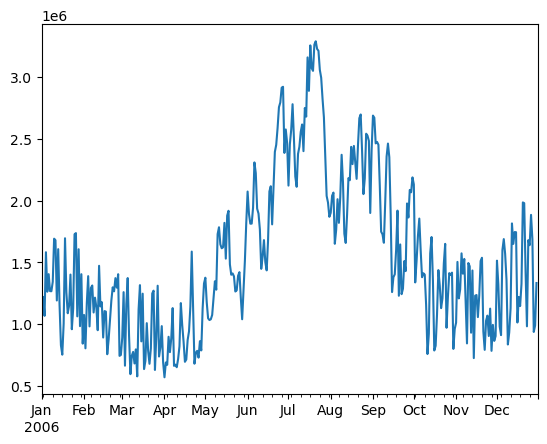

In [16]:
df_results["Cost"][::24].plot()

In [17]:
agg_load = 0
for node in system.nodes.values():
    agg_load += node.peak_load * node.load_profile

<Axes: xlabel='index'>

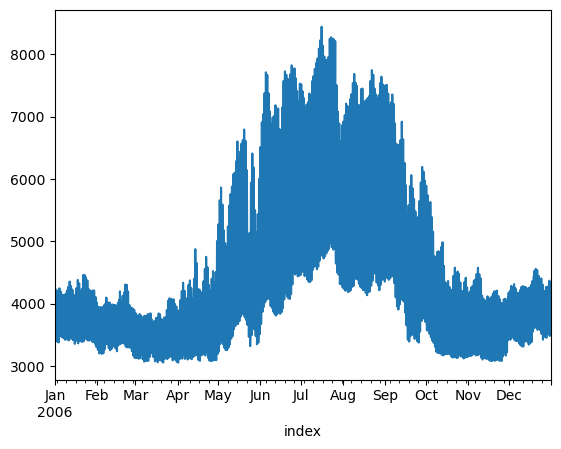

In [13]:
# System-wide aggregated load
agg_load.plot()

<Axes: xlabel='index'>

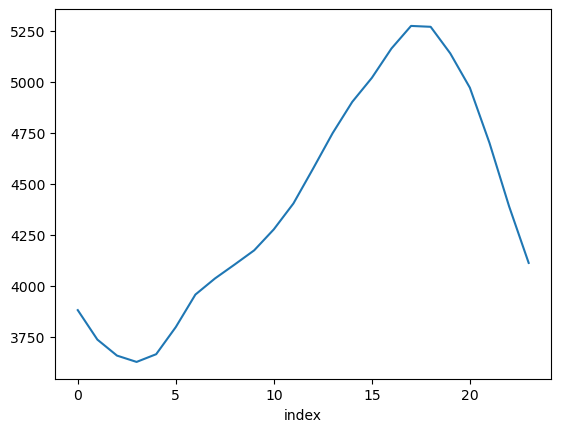

In [28]:
agg_load.shift(-8).groupby(agg_load.index.hour).mean().plot()

In [39]:
agg_load_gmlc = pd.read_csv("RTS-GMLC_aggregate_load.csv", index_col=[0])

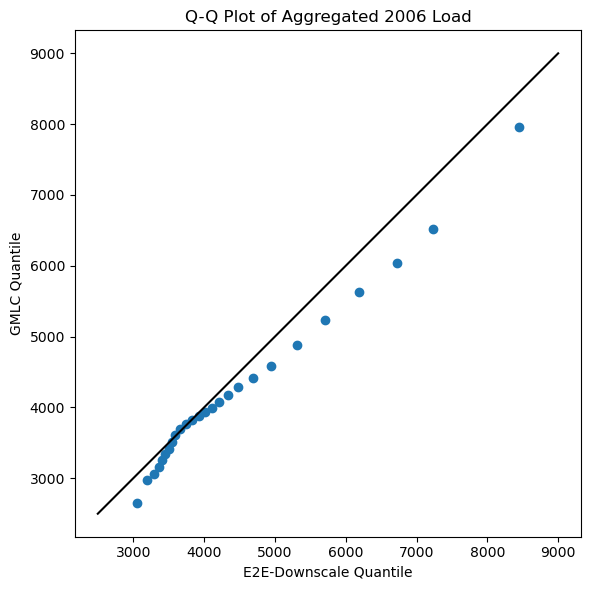

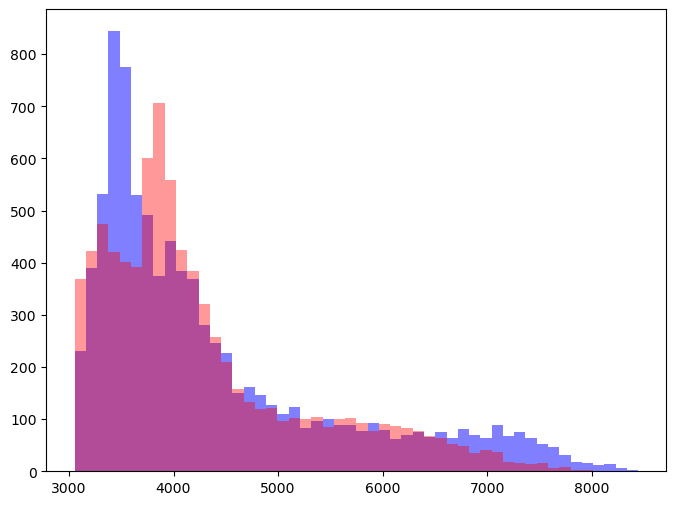

In [61]:
# Quantile-Quantile Plot
quantiles = np.linspace(0, 1, 26)
load_space = np.linspace(2500, 9000, 20)

plt.figure(figsize=(6,6))
plt.scatter(agg_load.quantile(quantiles), agg_load_gmlc.quantile(quantiles))
plt.plot(load_space, load_space, color="black")
plt.title("Q-Q Plot of Aggregated 2006 Load")
plt.xlabel("E2E-Downscale Quantile")
plt.ylabel("GMLC Quantile")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
_, bins, _ = plt.hist(agg_load.values, bins=50, alpha=0.5, color="blue")
plt.hist(agg_load_gmlc.values, bins=bins, alpha=0.4, color="red")
plt.show()

### Research Notes

The load seems to be slightly higher on average, even though the peaks are pretty close. This may be from giving such high weight to the top 5% of load hours while training the load model. We feel this is an acceptable tradeoff. The reliability of the power system is governed by extreme weather events that either drastically increase demand for power or severely reduce the available supply from generators. Therefore, we felt it important to give more weight in training to high demand days, as these are most impactful on power system reliability. However, for other tasks such as estimating the long-run average cost to operate the power system, this approach is not good. Our average cost is 153 million compared with 118 million per year. Still, I feel that this load model is acceptable, especially considering that we *trained the model on different load data* than what is in the GMLC system. Therefore it is entirely possible that we would differ by a few hundred megawatts in various quantiles. I am happy to proceed with this data set at this point!

### Next Steps...



In [20]:
for resource in system.variable_resources.values():
    if resource.resource_type == "solar":
        profile = resource.gen_profile
        break

In [21]:
profile

datetime
2006-01-01 00:00:00    0.029613
2006-01-01 01:00:00    0.000000
2006-01-01 02:00:00    0.000000
2006-01-01 03:00:00    0.000000
2006-01-01 04:00:00    0.000000
                         ...   
2006-12-31 19:00:00    0.571975
2006-12-31 20:00:00    0.407009
2006-12-31 21:00:00    0.577546
2006-12-31 22:00:00    0.621339
2006-12-31 23:00:00    0.627544
Name: p_mp, Length: 8760, dtype: float64

In [22]:
for resource in system.variable_resources.values():
    if resource.resource_type == "wind":
        profile = resource.gen_profile
        break

In [23]:
profile

datetime
2006-01-01 00:00:00    1.025000
2006-01-01 01:00:00    1.016600
2006-01-01 02:00:00    0.501473
2006-01-01 03:00:00    0.545793
2006-01-01 04:00:00    0.888800
                         ...   
2006-12-31 19:00:00    0.000000
2006-12-31 20:00:00    0.000000
2006-12-31 21:00:00    0.000000
2006-12-31 22:00:00    0.000000
2006-12-31 23:00:00    0.000000
Name: profile, Length: 8760, dtype: float64